In [22]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter
from sklearn import set_config
from sklearn.datasets import fetch_openml
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, accuracy_score, recall_score, precision_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler







In [23]:
# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
x, y = mnist.data, mnist.target.astype(int)  # Convert target to integer type

In [24]:
# Split into training (85%) and test (15%) sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, stratify=y, random_state=42)

# Verify that each class has an adequate number of instances
train_class_counts = Counter(y_train)
test_class_counts = Counter(y_test)

# Print the counts for each class
print("Training set class counts:", train_class_counts)
print("Test set class counts:", test_class_counts)

# Verify the split ratios
print("\nTraining set size:", len(x_train))
print("Test set size:", len(x_test))




Training set class counts: Counter({1: 6695, 7: 6199, 3: 6070, 2: 5942, 9: 5914, 0: 5868, 6: 5845, 8: 5801, 4: 5800, 5: 5366})
Test set class counts: Counter({1: 1182, 7: 1094, 3: 1071, 2: 1048, 9: 1044, 0: 1035, 6: 1031, 8: 1024, 4: 1024, 5: 947})

Training set size: 59500
Test set size: 10500


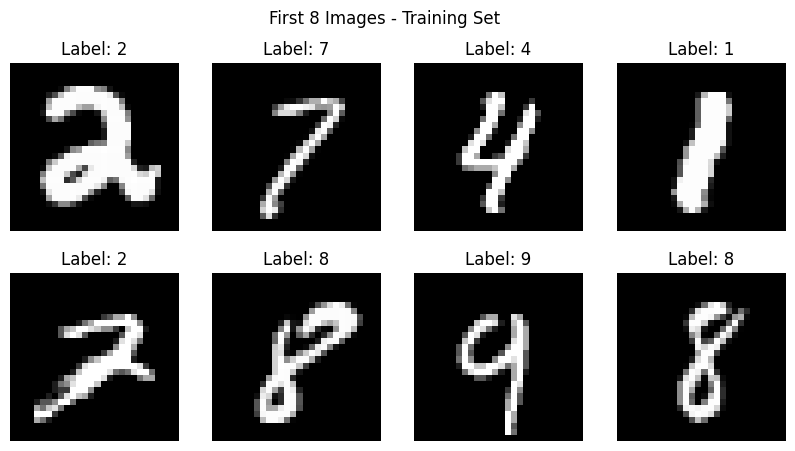

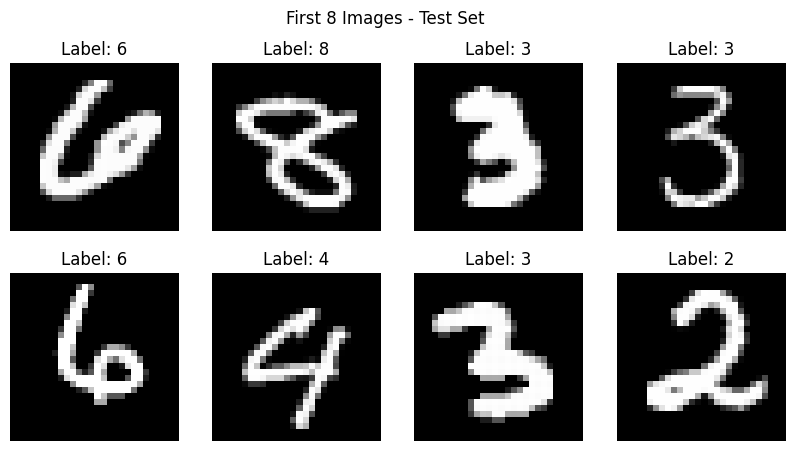

In [25]:
# Convert to NumPy arrays if they are pandas DataFrames
x_train = np.array(x_train) if not isinstance(x_train, np.ndarray) else x_train
y_train = np.array(y_train) if not isinstance(y_train, np.ndarray) else y_train
x_test = np.array(x_test) if not isinstance(x_test, np.ndarray) else x_test
y_test = np.array(y_test) if not isinstance(y_test, np.ndarray) else y_test

# Function to plot images in a 2x4 grid
def plot_images(data, labels, title):
    plt.figure(figsize=(10, 5))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(data[i].reshape(28, 28), cmap='gray')  # Reshape to 28x28 for visualization
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Plot the first 8 images of the training set
plot_images(x_train, y_train, "First 8 Images - Training Set")

# Plot the first 8 images of the test set
plot_images(x_test, y_test, "First 8 Images - Test Set")


In [26]:

# Transform labels to binary (even=0, odd=1)
y_train_binary = (y_train % 2 != 0).astype(int)  # 0 for even, 1 for odd
y_test_binary = (y_test % 2 != 0).astype(int)    # 0 for even, 1 for odd

# Create pipeline with normalization and classifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),                 # Normalization technique
    ('classifier', LogisticRegression())          # Binary classifier
])

# Enable display of pipeline diagram
set_config(display='diagram')

# Fit the pipeline to training data
pipeline.fit(x_train, y_train_binary)

# Display pipeline to visualize steps
pipeline


Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression())])

In [27]:
# Define scoring metrics for accuracy, recall, and precision
scoring_metrics = {
    'accuracy': make_scorer(accuracy_score),
    'recall': make_scorer(recall_score),
    'precision': make_scorer(precision_score)
}

# 3-fold cross-validation for the pipeline model
pipeline_scores = {
    metric: cross_val_score(pipeline, x_train, y_train_binary, cv=3, scoring=scoring)
    for metric, scoring in scoring_metrics.items()
}

# Display pipeline model scores
print("Pipeline Model Scores:")
for metric, scores in pipeline_scores.items():
    print(f"{metric.capitalize()}: {scores.mean():.4f} ± {scores.std():.4f}")

# Dummy classifier that always predicts "even" (0)
dummy = DummyClassifier(strategy="constant", constant=0)

# 3-fold cross-validation for the dummy classifier
dummy_scores = {
    metric: cross_val_score(dummy, x_train, y_train_binary, cv=3, scoring=scoring)
    for metric, scoring in scoring_metrics.items()
}

# Display dummy model scores
print("\nDummy Model Scores (always predicts 'even'):")
for metric, scores in dummy_scores.items():
    print(f"{metric.capitalize()}: {scores.mean():.4f} ± {scores.std():.4f}")


C:\Users\Loukas\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Loukas\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_

Pipeline Model Scores:
Accuracy: 0.8971 ± 0.0007
Recall: 0.9006 ± 0.0050
Precision: 0.8975 ± 0.0035


C:\Users\Loukas\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Loukas\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Dummy Model Scores (always predicts 'even'):
Accuracy: 0.4917 ± 0.0000
Recall: 0.0000 ± 0.0000
Precision: 0.0000 ± 0.0000


C:\Users\Loukas\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


C:\Users\Loukas\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


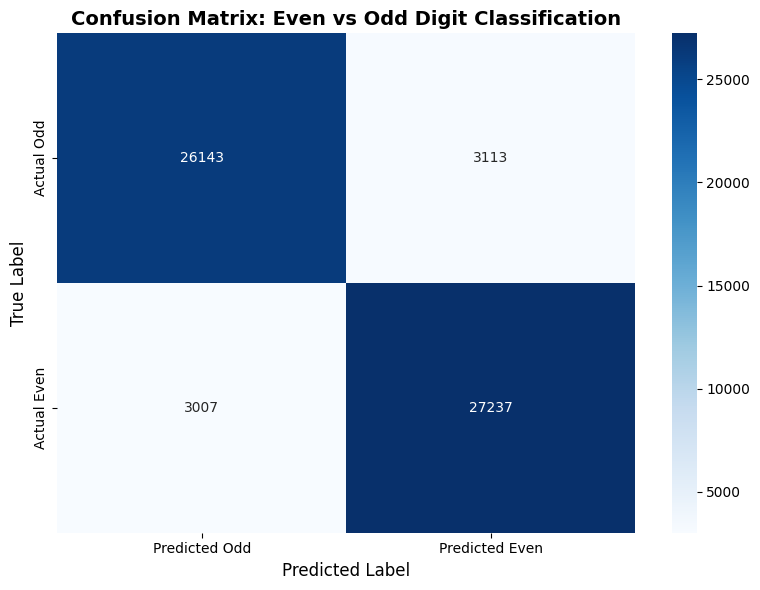

Confusion Matrix:
 [[26143  3113]
 [ 3007 27237]]

Prediction Types and Quantities:
True Negatives (Even classified as Even): 26143
False Positives (Odd classified as Even): 3113
False Negatives (Even classified as Odd): 3007
True Positives (Odd classified as Odd): 27237


In [28]:


# Generate cross-validated predictions for the training set
y_train_pred = cross_val_predict(pipeline, x_train, y_train_binary, cv=3)

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_train_binary, y_train_pred)

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,
    xticklabels=['Predicted Odd', 'Predicted Even'],
    yticklabels=['Actual Odd', 'Actual Even']
)
plt.title('Confusion Matrix: Even vs Odd Digit Classification', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Display the confusion matrix
print("Confusion Matrix:\n", conf_matrix)

# Interpret the confusion matrix
tn, fp, fn, tp = conf_matrix.ravel()
print("\nPrediction Types and Quantities:")
print(f"True Negatives (Even classified as Even): {tn}")
print(f"False Positives (Odd classified as Even): {fp}")
print(f"False Negatives (Even classified as Odd): {fn}")
print(f"True Positives (Odd classified as Odd): {tp}")


In [29]:
# Train the pipeline on the entire training set
pipeline.fit(x_train, y_train_binary)

# Generate predictions for the test set
y_test_pred = pipeline.predict(x_test)

# Calculate the confusion matrix for the test set predictions
conf_matrix_test = confusion_matrix(y_test_binary, y_test_pred)

# Display the confusion matrix for the test set
print("Confusion Matrix on Test Set:\n", conf_matrix_test)

# Interpret the confusion matrix for the test set
tn_test, fp_test, fn_test, tp_test = conf_matrix_test.ravel()
print("\nPrediction Types and Quantities on Test Set:")
print(f"True Negatives (Even classified as Even): {tn_test}")
print(f"False Positives (Odd classified as Even): {fp_test}")
print(f"False Negatives (Even classified as Odd): {fn_test}")
print(f"True Positives (Odd classified as Odd): {tp_test}")


Confusion Matrix on Test Set:
 [[4630  532]
 [ 479 4859]]

Prediction Types and Quantities on Test Set:
True Negatives (Even classified as Even): 4630
False Positives (Odd classified as Even): 532
False Negatives (Even classified as Odd): 479
True Positives (Odd classified as Odd): 4859


C:\Users\Loukas\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Loukas\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


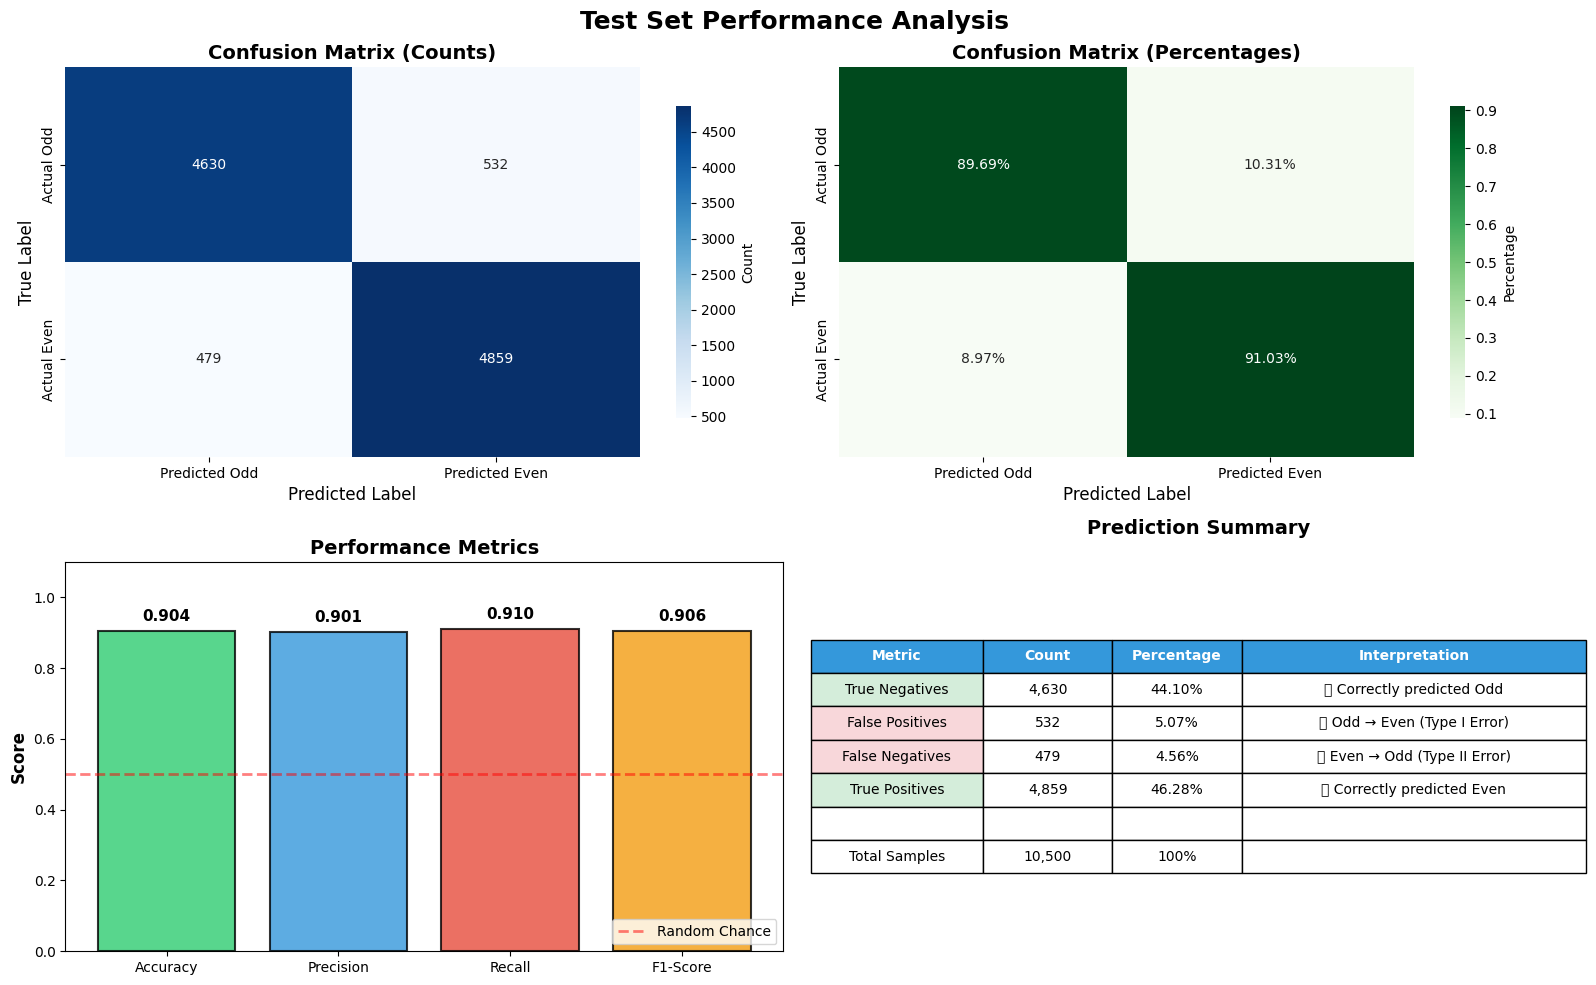

In [30]:
# Calculate metrics
accuracy = accuracy_score(y_test_binary, y_test_pred)
precision = precision_score(y_test_binary, y_test_pred)
recall = recall_score(y_test_binary, y_test_pred)
f1 = f1_score(y_test_binary, y_test_pred)

# Create comprehensive dashboard
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Test Set Performance Analysis', fontsize=18, fontweight='bold', y=0.98)

# 1. Confusion Matrix Heatmap (Top Left)
ax1 = plt.subplot(2, 2, 1)
sns.heatmap(
    conf_matrix_test, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    ax=ax1,
    xticklabels=['Predicted Odd', 'Predicted Even'],
    yticklabels=['Actual Odd', 'Actual Even'],
    cbar_kws={'label': 'Count', 'shrink': 0.8}
)
ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=12)
ax1.set_ylabel('True Label', fontsize=12)

# 2. Normalized Confusion Matrix (Top Right)
ax2 = plt.subplot(2, 2, 2)
conf_matrix_norm = conf_matrix_test.astype('float') / conf_matrix_test.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    conf_matrix_norm, 
    annot=True, 
    fmt='.2%', 
    cmap='Greens',
    ax=ax2,
    xticklabels=['Predicted Odd', 'Predicted Even'],
    yticklabels=['Actual Odd', 'Actual Even'],
    cbar_kws={'label': 'Percentage', 'shrink': 0.8}
)
ax2.set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=12)
ax2.set_ylabel('True Label', fontsize=12)

# 3. Metrics Bar Chart (Bottom Left)
ax3 = plt.subplot(2, 2, 3)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

bars = ax3.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_ylim([0, 1.1])
ax3.set_ylabel('Score', fontsize=12, fontweight='bold')
ax3.set_title('Performance Metrics', fontsize=14, fontweight='bold')
ax3.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Random Chance')
ax3.legend(loc='lower right')

# Add value labels on bars
for bar, value in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# 4. Prediction Summary Table (Bottom Right)
ax4 = plt.subplot(2, 2, 4)
ax4.axis('tight')
ax4.axis('off')

# Prepare data for table
tn, fp, fn, tp = conf_matrix_test.ravel()
total = conf_matrix_test.sum()

table_data = [
    ['Metric', 'Count', 'Percentage', 'Interpretation'],
    ['True Negatives', f'{tn:,}', f'{tn/total:.2%}', '✅ Correctly predicted Odd'],
    ['False Positives', f'{fp:,}', f'{fp/total:.2%}', '❌ Odd → Even (Type I Error)'],
    ['False Negatives', f'{fn:,}', f'{fn/total:.2%}', '❌ Even → Odd (Type II Error)'],
    ['True Positives', f'{tp:,}', f'{tp/total:.2%}', '✅ Correctly predicted Even'],
    ['', '', '', ''],
    ['Total Samples', f'{total:,}', '100%', '']
]

table = ax4.table(
    cellText=table_data,
    cellLoc='center',
    loc='center',
    colWidths=[0.2, 0.15, 0.15, 0.4]
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Color the header row
for i in range(4):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Color the summary rows
for i in [1, 4]:  # True Negatives and True Positives
    table[(i, 0)].set_facecolor('#d4edda')
for i in [2, 3]:  # False Positives and False Negatives
    table[(i, 0)].set_facecolor('#f8d7da')

ax4.set_title('Prediction Summary', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

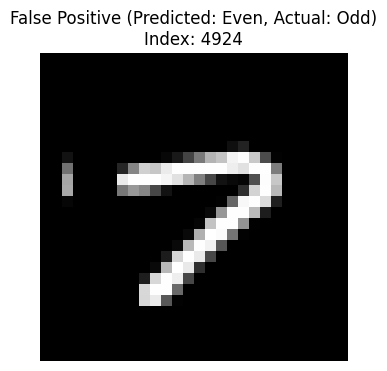

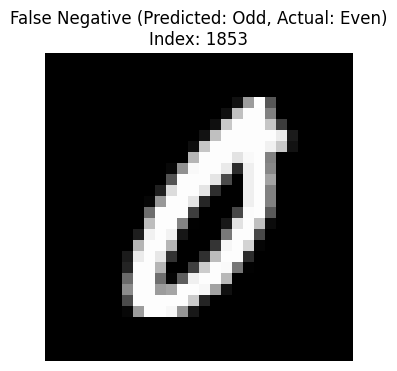

In [31]:
# Identify false positives and false negatives
false_positives = np.where((y_test_pred == 0) & (y_test_binary == 1))[0]  # Predicted even, actually odd
false_negatives = np.where((y_test_pred == 1) & (y_test_binary == 0))[0]  # Predicted odd, actually even

# Select one random instance from each group
random_fp_index = np.random.choice(false_positives)
random_fn_index = np.random.choice(false_negatives)

# Plot the false positive instance
plt.figure(figsize=(4, 4))
plt.imshow(x_test[random_fp_index].reshape(28, 28), cmap='gray')
plt.title(f"False Positive (Predicted: Even, Actual: Odd)\nIndex: {random_fp_index}")
plt.axis('off')
plt.show()

# Plot the false negative instance
plt.figure(figsize=(4, 4))
plt.imshow(x_test[random_fn_index].reshape(28, 28), cmap='gray')
plt.title(f"False Negative (Predicted: Odd, Actual: Even)\nIndex: {random_fn_index}")
plt.axis('off')
plt.show()